In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression,Lasso,Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,confusion_matrix


In [32]:
iris_df=pd.read_csv("iris.csv")
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [50]:
le=LabelEncoder()
iris_df["Species"]=le.fit_transform(iris_df["Species"])
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [52]:
X=iris_df.drop(columns=["Species"])
y=iris_df["Species"]


In [76]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [77]:
#logistic regression
logistic=LogisticRegression(max_iter=1000)
logistic.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
#Ridge
ridge=LogisticRegression(penalty="l2",C=1,max_iter=1000)
ridge.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [79]:
#KNN
classifier=KNeighborsClassifier()
param_grid={"n_neighbors":[3,5,7,9,11,13]}

clCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5,
    scoring="recall_weighted"
)
clCV.fit(X_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'recall_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [80]:
#naive base
NB=GaussianNB()
NB.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [84]:
models={"LOGISTIC_REGRESSION":logistic,"KNN":clCV,"NAIVE BAYES":NB,"Ridge":ridge}

for name,model in models.items():
    y_pred=model.predict(X_test)
    print(f"\n{name}")
    cm=confusion_matrix(y_test,y_pred)
    print(cm)
    print(f"Accuracy : {accuracy_score(y_test,y_pred)}")
    print(f"Recall : {recall_score(y_test,y_pred,average="weighted")}")
    print(classification_report(y_test,y_pred))



LOGISTIC_REGRESSION
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy : 1.0
Recall : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


KNN
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy : 1.0
Recall : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


NAIVE BAYES
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy : 1.0
Recall : 1.0
    

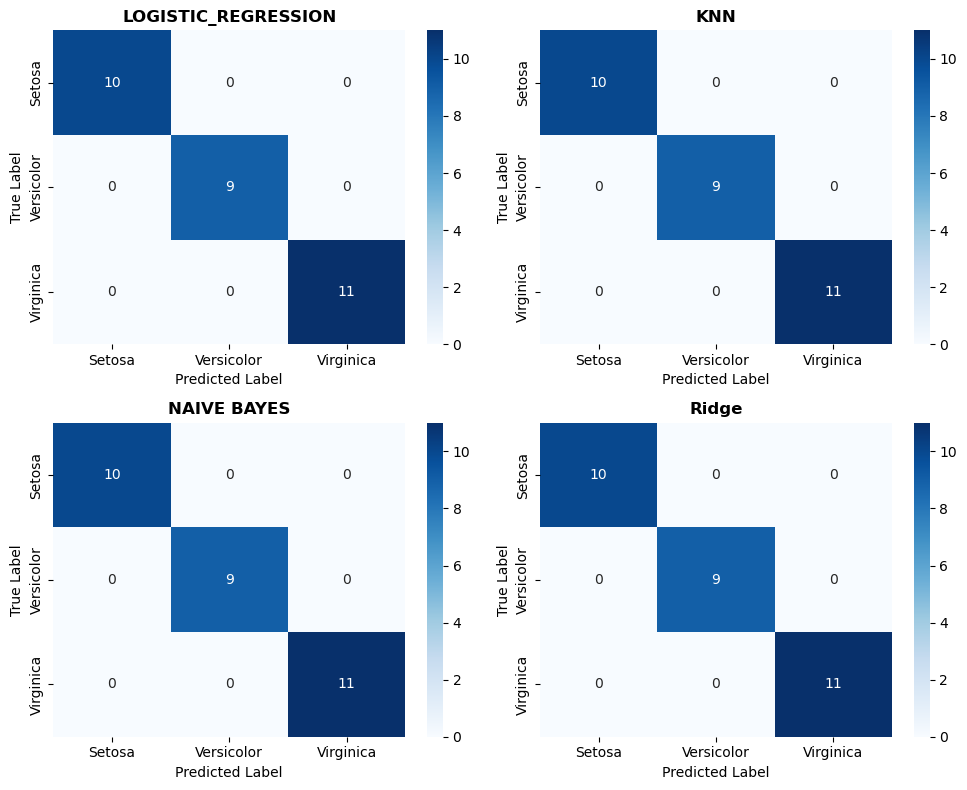

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a 2x2 grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # Convert 2D axes array to 1D array for easy looping

class_names = ["Setosa", "Versicolor", "Virginica"]

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=True,
        xticklabels=class_names, 
        yticklabels=class_names, 
        ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("Models-result.png", dpi=300, bbox_inches="tight")
plt.show()